In [70]:
from __future__ import annotations

import anndata as ad
import decoupler
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn.objects as so
import session_info
import gseapy as gp
import pylimma

In [4]:
gp.__version__

'1.1.11'

In [71]:
pylimma.__version__

'0.1.0'

In [ ]:
endo_ann = sc.read("endo_scvi_annotated.h5ad")

In [58]:
pdata = sc.read("pdata.h5ad")

In [63]:
pdata

AnnData object with n_obs × n_vars = 50 × 2000
    obs: 'Donor', 'cell_type', 'predicted_doublet', 'Status', 'Phase', 'Study', 'Instrument', '_scvi_batch', '_scvi_labels', 'leiden_0_25', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'X', 'counts', 'psbulk_props'

In [69]:
stroma = pdata[pdata.obs["cell_type"] == "eStroma"].copy()

In [72]:
# Extract the raw count matrix (Genes x Samples)
counts = pd.DataFrame(stroma.X.toarray().T, index=stroma.var_names, columns=stroma.obs_names)

# Build design matrix (e.g., matching Control vs Treated)
# Assign 1 for Treatment, 0 for Control
design = pd.DataFrame({
    'Intercept': 1,
    'Treatment': stroma.obs['Status'].map({'Control': 0, 'Thin': 1}).values
}, index=stroma.obs_names)

# Filter out low-expressed genes before voom
is_expressed = counts.sum(axis=1) > 10
counts_filtered = counts.loc[is_expressed]

# Apply voom normalization to calculate precision weights
v_object = lm.voom(counts_filtered, design)

# Fit linear model using the calculated weights
fit = lm.lm_fit(v_object, design)

# Compute Empirical Bayes moderation to stabilize variance
fit = lm.e_bayes(fit)

# Extract top table metrics for the 'Treatment' contrast
de_results = lm.top_table(fit, coef='Treatment', number=np.inf)


AttributeError: 'numpy.ndarray' object has no attribute 'toarray'

In [62]:
stroma

AnnData object with n_obs × n_vars = 7 × 2000
    obs: 'Donor', 'cell_type', 'predicted_doublet', 'Status', 'Phase', 'Study', 'Instrument', '_scvi_batch', '_scvi_labels', 'leiden_0_25', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'X', 'counts', 'psbulk_props'

In [11]:
dc.pp.filter_by_expr(
    adata=stroma,
    group="Status",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=stroma,
    min_prop=0.1,
    min_smpls=2,
)
stroma

AnnData object with n_obs × n_vars = 7 × 716
    obs: 'Donor', 'cell_type', 'predicted_doublet', 'Status', 'Phase', 'Study', 'Instrument', '_scvi_batch', '_scvi_labels', 'leiden_0_25', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'X', 'counts', 'psbulk_props'

In [14]:
stroma_pds2 = pt.tl.PyDESeq2(adata=stroma, design="~Status")

In [15]:
stroma_pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.21 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.44 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [16]:
stroma_df = stroma_pds2.test_contrasts(stroma_pds2.contrast(column="Status", baseline="Control", group_to_compare="Thin"))

Running Wald tests...
... done in 0.17 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
VWA1     291.374629       -0.505064  0.764093 -0.660998  0.508614  0.674401
ERRFI1  4774.470138        0.023996  0.698628  0.034347  0.972600  0.985069
HSPG2   1314.462064       -0.403308  0.499643 -0.807191  0.419556  0.601421
ID3     5190.055375       -0.953681  0.661748 -1.441153  0.149541  0.323173
SFN       90.043776       -1.948392  1.364249 -1.428180  0.153240  0.326209
...             ...             ...       ...       ...       ...       ...
FGF13   5255.314009        0.785612  0.408484  1.923240  0.054450  0.164740
CETN2   1819.150681        0.598465  0.487385  1.227911  0.219480  0.405326
BGN      666.905353        1.107289  0.616782  1.795268  0.072611  0.199330
CLIC2    672.141125        0.308339  0.509282  0.605439  0.544887  0.701838
TTTY14   442.764606       -1.853476  1.219401 -1.519990  0.128514  0.293804

[716 rows x 6 columns]


In [18]:
stroma_dge_df = stroma_df[stroma_df['adj_p_value'] < 0.05]

In [27]:
stroma_dge_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,TULP2,1378.593241,-5.169295,0.594437,-8.696125,3.434116e-18,2.441657e-15,None
1,ATCAY,276.992509,-5.268548,0.735668,-7.161584,7.975018e-13,2.835119e-10,None
2,ENSG00000267011,215.080048,-3.935703,0.560163,-7.025998,2.125417e-12,5.037237e-10,None
3,RAD54L,250.898361,-3.453882,0.527893,-6.542771,6.038944e-11,1.073422e-08,None
4,CRIP1,1358.655926,-2.711589,0.440470,-6.156124,7.454701e-10,1.060058e-07,None
...,...,...,...,...,...,...,...,...
127,SFRP4,113898.519469,2.459349,0.928480,2.648790,8.078062e-03,4.465475e-02,None
128,H1-3,181.910252,1.516256,0.572649,2.647793,8.101917e-03,4.465475e-02,None
129,CCBE1,5614.144130,2.200766,0.841390,2.615631,8.906272e-03,4.871046e-02,None
130,LAMA3,2851.051631,2.197726,0.844219,2.603265,9.234068e-03,4.995291e-02,None


In [32]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'BrainRanger_Regions_ARCHS4_2026',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',


In [83]:
pre_res_pseudo = gp.prerank(stroma_df.loc[:, ["variable", "log_fc"]], 
                            gene_sets = 'GO_Biological_Process_2026', 
                            seed=42, 
                            min_size = 5,
                            max_size = 1000,
                            permutation_num = 1000)

In [84]:
prerank_df = pre_res_pseudo.res2d

In [85]:
prerank_df.head(50)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Positive Regulation of Extrinsic Apoptotic Sig...,0.840271,1.857503,0.002833,0.580787,0.359,4/6,6.98%,SFRP1;HYAL2;CAV1;TNFRSF12A
1,prerank,Homophilic Cell-Cell Adhesion (GO:0007156),0.751544,1.82281,0.003003,0.432376,0.482,6/8,16.76%,TGFBI;CADM1;ROBO2;CLSTN2;POSTN;HMCN1
2,prerank,Response to Transforming Growth Factor Beta (G...,0.866019,1.796301,0.005076,0.399693,0.571,4/5,9.64%,SFRP1;HYAL2;SOX6;PDE3A
3,prerank,Regulation of Anatomical Structure Morphogenes...,-0.688114,-1.737121,0.002632,0.506956,0.339,6/17,8.10%,CXCL13;IL6;CLDN3;PID1;KCTD12;CLDN4
4,prerank,Regulation of Potassium Ion Transmembrane Tran...,0.772743,1.715,0.021798,0.669995,0.817,3/6,6.42%,KCNIP4;CAV1;DPP6
5,prerank,Negative Regulation of Response to Stimulus (G...,0.76163,1.688511,0.021472,0.686014,0.878,2/6,1.40%,EPHA5;THY1
6,prerank,Heart Development (GO:0007507),-0.644554,-1.64496,0.003807,1.0,0.761,9/19,20.81%,DKK1;CRIP1;NTRK3;SOX17;FN1;HDAC9;TGFBR3;PDLIM1...
7,prerank,DNA Damage Response (GO:0006974),-0.697145,-1.625554,0.008523,0.962733,0.849,6/12,20.81%,RAD54L;CRIP1;NABP1;SFN;CDKN2AIP;CDKN1A
8,prerank,Positive Regulation of Chemotaxis (GO:0050921),-0.726379,-1.625003,0.008798,0.728809,0.85,5/10,13.41%,IL6;NTRK3;MET;SEMA5A;PDGFRA
9,prerank,Regulation of Immune Response (GO:0050776),-0.804085,-1.597284,0.015337,0.84145,0.924,1/7,0.28%,CXCL13


In [89]:
term2.head(20)

0     Positive Regulation of Extrinsic Apoptotic Sig...
1            Homophilic Cell-Cell Adhesion (GO:0007156)
2     Response to Transforming Growth Factor Beta (G...
3     Regulation of Anatomical Structure Morphogenes...
4     Regulation of Potassium Ion Transmembrane Tran...
5     Negative Regulation of Response to Stimulus (G...
6                        Heart Development (GO:0007507)
7                      DNA Damage Response (GO:0006974)
8        Positive Regulation of Chemotaxis (GO:0050921)
9            Regulation of Immune Response (GO:0050776)
10              Regulation of Axonogenesis (GO:0050770)
11     Non-canonical Wnt Signaling Pathway (GO:0035567)
12    External Encapsulating Structure Organization ...
13    Extracellular Structure Organization (GO:0043062)
14     Cytokine-mediated Signaling Pathway (GO:0019221)
15    Regulation of Fat Cell Differentiation (GO:004...
16    Plasma Membrane Bounded Cell Projection Organi...
17              Regulation of Neurogenesis (GO:0

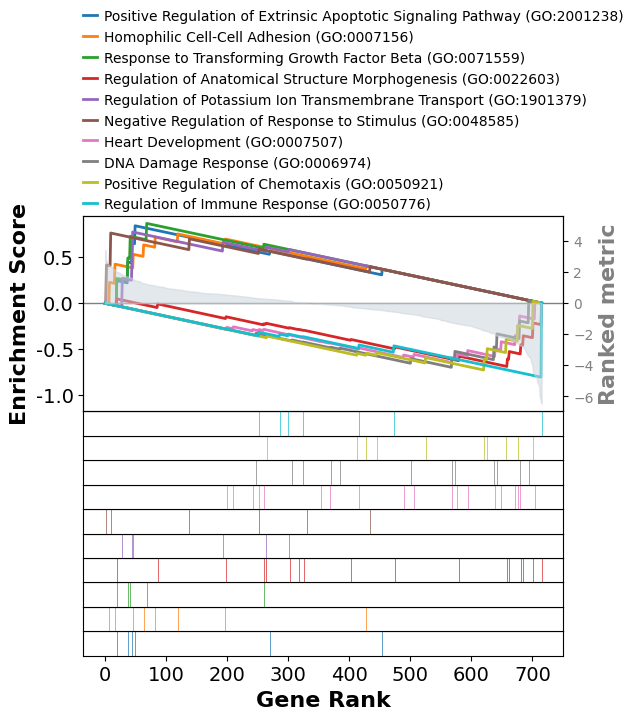

In [102]:
term2 = pre_res_pseudo.res2d.Term
axes = pre_res_pseudo.plot(terms=term2[:10])
axes.savefig('stroma_gsea_plot.png', dpi=300, bbox_inches='tight')

In [103]:
stroma_dge_df = stroma_df[stroma_df['adj_p_value'] < 0.05]
stroma_dge_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,TULP2,1378.593241,-5.169295,0.594437,-8.696125,3.434116e-18,2.441657e-15,None
1,ATCAY,276.992509,-5.268548,0.735668,-7.161584,7.975018e-13,2.835119e-10,None
2,ENSG00000267011,215.080048,-3.935703,0.560163,-7.025998,2.125417e-12,5.037237e-10,None
3,RAD54L,250.898361,-3.453882,0.527893,-6.542771,6.038944e-11,1.073422e-08,None
4,CRIP1,1358.655926,-2.711589,0.440470,-6.156124,7.454701e-10,1.060058e-07,None
...,...,...,...,...,...,...,...,...
127,SFRP4,113898.519469,2.459349,0.928480,2.648790,8.078062e-03,4.465475e-02,None
128,H1-3,181.910252,1.516256,0.572649,2.647793,8.101917e-03,4.465475e-02,None
129,CCBE1,5614.144130,2.200766,0.841390,2.615631,8.906272e-03,4.871046e-02,None
130,LAMA3,2851.051631,2.197726,0.844219,2.603265,9.234068e-03,4.995291e-02,None


In [105]:
stroma_up = stroma_dge_df[stroma_dge_df['log_fc'] > 0]
stroma_dw = stroma_dge_df[stroma_dge_df['log_fc'] < 0]

In [108]:
stroma_up

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
14,CSMD1,690.201093,2.798426,0.539965,5.182606,2.188065e-07,0.000010,None
23,THY1,7520.435815,2.335715,0.544912,4.286409,1.815842e-05,0.000538,None
30,EPHA5,2794.836425,2.744521,0.668223,4.107193,4.004961e-05,0.000912,None
31,IL32,3249.095549,2.397079,0.584440,4.101498,4.104846e-05,0.000912,None
38,GNG4,849.858598,1.733763,0.454065,3.818316,1.343658e-04,0.002360,None
42,TUBA1A,17801.239035,1.631834,0.429176,3.802251,1.433876e-04,0.002360,None
43,LMO2,343.821649,1.850934,0.487907,3.793620,1.484671e-04,0.002360,None
45,TMEM106C,201.429813,2.327067,0.619508,3.756312,1.724358e-04,0.002665,None
46,ITPR2-AS1,357.576593,1.976512,0.530650,3.724698,1.955493e-04,0.002958,None
47,TGFBI,4554.413553,2.429050,0.654828,3.709449,2.077109e-04,0.003077,None


In [129]:
enr_up = gp.enrichr(stroma_up.variable,
                    gene_sets='KEGG_2026',
                    outdir=None)
#Same for GO BP

In [130]:
enr_up.res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2026,GAP JUNCTION,2/85,0.009698,0.312519,0,0,14.517707,67.302430,TUBB2B;TUBA1A
1,KEGG_2026,PHAGOSOME,2/151,0.028632,0.312519,0,0,8.060199,28.639622,TUBB2B;TUBA1A
2,KEGG_2026,GLYCOSAMINOGLYCAN DEGRADATION,1/18,0.031049,0.312519,0,0,34.512111,119.833011,HYAL2
3,KEGG_2026,AXON GUIDANCE,2/178,0.038681,0.312519,0,0,6.814394,22.163221,EPHA5;SEMA3A
4,KEGG_2026,MOTOR PROTEINS,2/190,0.043520,0.312519,0,0,6.375564,19.984407,TUBB2B;TUBA1A
5,KEGG_2026,NEUROACTIVE LIGAND SIGNALING,2/195,0.045600,0.312519,0,0,6.208824,19.171845,GNG4;PENK
6,KEGG_2026,PATHOGENIC ESCHERICHIA COLI INFECTION,2/198,0.046866,0.312519,0,0,6.112863,18.708174,TUBB2B;TUBA1A
7,KEGG_2026,HORMONE SIGNALING,2/218,0.055628,0.312519,0,0,5.541246,16.009073,GNG4;PENK
8,KEGG_2026,AFRICAN TRYPANOSOMIASIS,1/37,0.062806,0.312519,0,0,16.281863,45.063408,LAMA4
9,KEGG_2026,SALMONELLA INFECTION,2/244,0.067802,0.312519,0,0,4.939394,13.292707,TUBB2B;TUBA1A


In [116]:
ax = gp.barplot(enr_up.res2d,title='Upregulated Pathways in TE Stroma', top_term = 20)

ValueError: Warning: No enrich terms when cutoff = 0.05

In [135]:
enr_dw = gp.enrichr(stroma_dw.variable,
                    gene_sets='KEGG_2026',
                    outdir=None)

In [137]:
enr_dw.res2d.head(50)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2026,AMOEBIASIS,5/100,0.000127,0.016195,0,0,11.331808,101.703770,IL6;ARG2;LAMA2;FN1;SERPINB9
1,KEGG_2026,INTEGRIN SIGNALING,4/153,0.006580,0.342856,0,0,5.702244,28.646175,PDGFRA;LAMA2;FN1;FLNB
2,KEGG_2026,VIRAL PROTEIN INTERACTION WITH CYTOKINE AND CY...,3/99,0.012399,0.342856,0,0,6.584774,28.907951,IL6;ACKR3;CXCL13
3,KEGG_2026,MOTOR PROTEINS,4/190,0.013780,0.342856,0,0,4.559371,19.534906,DNAH12;MYO10;TUBD1;MYH11
4,KEGG_2026,AFRICAN TRYPANOSOMIASIS,2/37,0.013885,0.342856,0,0,11.950677,51.112087,IL6;APOL1
5,KEGG_2026,FOCAL ADHESION,4/199,0.016071,0.342856,0,0,4.346953,17.956032,PDGFRA;LAMA2;FN1;FLNB
6,KEGG_2026,CHOLESTEROL METABOLISM,2/51,0.025445,0.465279,0,0,8.530183,31.316333,LIPG;APOC1
7,KEGG_2026,PI3K-AKT SIGNALING PATHWAY,5/355,0.029334,0.469345,0,0,3.036180,10.714698,PDGFRA;IL6;KITLG;LAMA2;FN1
8,KEGG_2026,PATHWAYS IN CANCER,6/525,0.042501,0.541271,0,0,2.462555,7.777313,PDGFRA;IL6;KITLG;LAMA2;ZBTB16;FN1
9,KEGG_2026,CENTRAL CARBON METABOLISM IN CANCER,2/68,0.043124,0.541271,0,0,6.327592,19.891889,PDGFRA;NTRK3


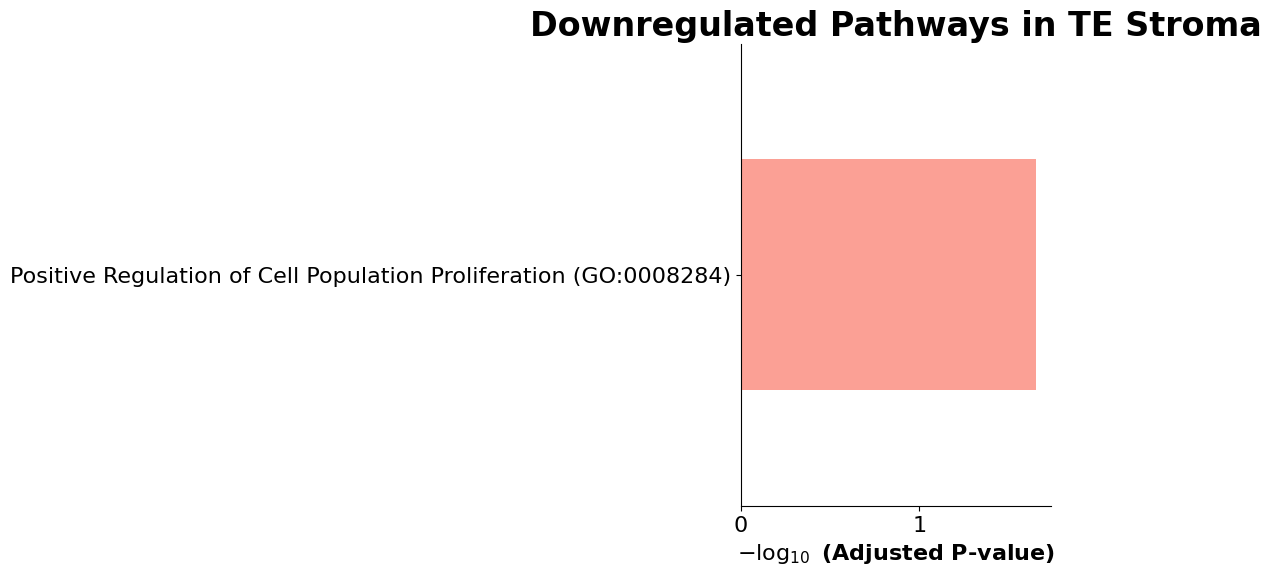

In [125]:
ax = gp.barplot(enr_dw.res2d,title='Downregulated Pathways in TE Stroma', top_term = 20)

In [44]:
epi = pdata[pdata.obs["cell_type"] == "Unciliated Epithelium"].copy()

In [45]:
dc.pp.filter_by_expr(
    adata=epi,
    group="Status",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=epi,
    min_prop=0.1,
    min_smpls=2,
)
epi

AnnData object with n_obs × n_vars = 7 × 986
    obs: 'Donor', 'cell_type', 'predicted_doublet', 'Status', 'Phase', 'Study', 'Instrument', '_scvi_batch', '_scvi_labels', 'leiden_0_25', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'X', 'counts', 'psbulk_props'

In [46]:
epi_pds2 = pt.tl.PyDESeq2(adata=epi, design="~Status")

In [47]:
epi_pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.22 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.25 seconds.

Fitting LFCs...
... done in 0.20 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [48]:
epi_df = epi_pds2.test_contrasts(epi_pds2.contrast(column="Status", baseline="Control", group_to_compare="Thin"))

Running Wald tests...
... done in 0.20 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
VWA1         317.903434        0.547551  0.607285  0.901638  0.367249   
ERRFI1     16615.431671        0.596489  0.464388  1.284463  0.198980   
ERRFI1-DT    755.872700        0.782590  0.440789  1.775432  0.075827   
FHAD1        222.536378       -2.643124  0.603433 -4.380148  0.000012   
SRARP        322.207804        1.670050  1.092365  1.528838  0.126305   
...                 ...             ...       ...       ...       ...   
ZCCHC12       89.797925        2.391557  0.796673  3.001931  0.002683   
LINC01285   1441.893967        1.210161  0.665610  1.818123  0.069045   
FGF13      12099.153573       -0.542255  0.668382 -0.811294  0.417197   
CETN2        944.806576       -0.497215  0.457290 -1.087308  0.276901   
TTTY14      1064.302658       -3.472369  0.966103 -3.594202  0.000325   

               padj  
VWA1       0.599489  
ERRFI1     0.405

In [97]:
pre_res_epi = gp.prerank(epi_df.loc[:, ["variable", "log_fc"]], 
                            gene_sets = 'GO_Biological_Process_2026', 
                            seed=42, 
                            min_size = 5,
                            max_size = 1000,
                            permutation_num = 1000)

In [101]:
pre_res_epi.res2d.head(50)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Response to Copper Ion (GO:0046688),-0.850638,-1.864396,0.0,0.064895,0.056,6/10,7.40%,MT1H;MT1M;MT1G;MT1E;MT1F;MT1X
1,prerank,Cellular Response to Cadmium Ion (GO:0071276),-0.872947,-1.82432,0.0,0.025745,0.123,6/8,7.40%,MT1H;MT1M;MT1G;MT1E;MT1F;MT1X
2,prerank,Cellular Response to Zinc Ion (GO:0071294),-0.872947,-1.82432,0.0,0.025745,0.123,6/8,7.40%,MT1H;MT1M;MT1G;MT1E;MT1F;MT1X
3,prerank,Intracellular Zinc Ion Homeostasis (GO:0006882),-0.872947,-1.82432,0.0,0.025745,0.123,6/8,7.40%,MT1H;MT1M;MT1G;MT1E;MT1F;MT1X
4,prerank,Cellular Response to Copper Ion (GO:0071280),-0.872947,-1.82432,0.0,0.025745,0.123,6/8,7.40%,MT1H;MT1M;MT1G;MT1E;MT1F;MT1X
5,prerank,Response to Cadmium Ion (GO:0046686),-0.872947,-1.82432,0.0,0.025745,0.123,6/8,7.40%,MT1H;MT1M;MT1G;MT1E;MT1F;MT1X
6,prerank,Extracellular Matrix Organization (GO:0030198),0.523448,1.812207,0.004444,1.0,0.545,10/27,10.45%,MMP11;HPSE2;COL5A1;HMCN1;LUM;COL1A1;COL5A2;MMP...
7,prerank,Response to Zinc Ion (GO:0010043),-0.836333,-1.792399,0.0,0.039694,0.198,6/9,7.40%,MT1H;MT1M;MT1G;MT1E;MT1F;MT1X
8,prerank,Collagen Fibril Organization (GO:0030199),0.668718,1.787538,0.015337,0.817515,0.635,8/11,23.63%,COL5A1;LUM;COL1A1;COL5A2;FBN1;COL3A1;COL14A1;L...
9,prerank,Intracellular Monoatomic Cation Homeostasis (G...,-0.67418,-1.784869,0.0,0.03896,0.216,8/25,7.40%,MT1H;MT1M;MT1G;MT1E;CP;SLC8A2;MT1F;MT1X


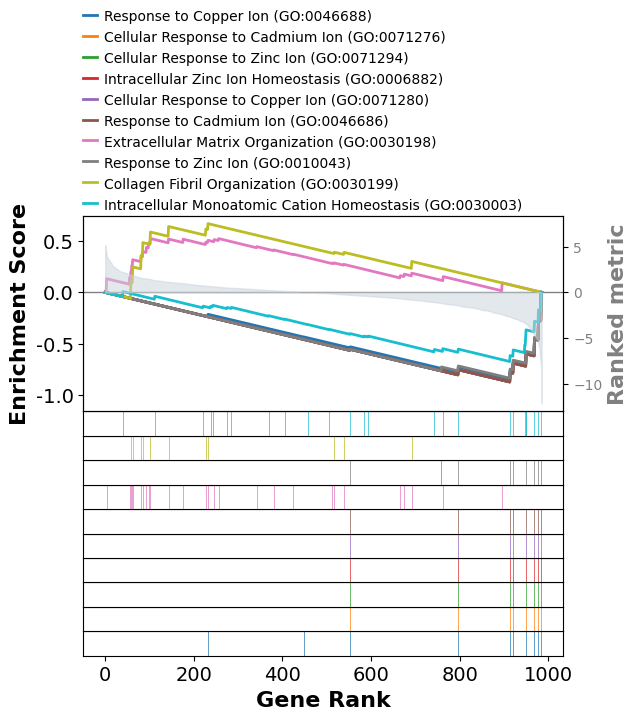

In [98]:
term2 = pre_res_epi.res2d.Term
axes = pre_res_epi.plot(terms=term2[:10])
axes.savefig('epi_gsea_plot.png', dpi=300, bbox_inches='tight')

In [117]:
epi_dge_df = epi_df[epi_df['adj_p_value'] < 0.05]

In [118]:
epi_dge_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,RAD54L,1907.190843,-5.217182,0.693618,-7.521688,5.407344e-14,5.234309e-11,None
1,CLDN22,374.571472,-6.333983,0.916366,-6.912065,4.776502e-12,2.311827e-09,None
2,PTGS1,604.289581,-5.150345,0.810975,-6.350803,2.141942e-10,5.691552e-08,None
3,SFRP4,3452.526735,4.743041,0.748538,6.336405,2.351881e-10,5.691552e-08,None
4,FGF14,529.482921,-5.800987,0.952955,-6.087366,1.147835e-09,2.222209e-07,None
...,...,...,...,...,...,...,...,...
185,SLC35F3,289.828240,-1.645973,0.627403,-2.623471,8.703887e-03,4.515784e-02,None
186,DLGAP1-AS1,1681.133791,1.490228,0.568406,2.621767,8.747519e-03,4.515784e-02,None
187,ADAMTS8,873.415591,-2.407824,0.919077,-2.619828,8.797419e-03,4.515784e-02,None
188,NFKBIA,29658.359371,0.715308,0.273115,2.619070,8.816976e-03,4.515784e-02,None


In [119]:
epi_up = epi_dge_df[epi_dge_df['log_fc'] > 0]
epi_dw = epi_dge_df[epi_dge_df['log_fc'] < 0]

In [120]:
epi_up

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
3,SFRP4,3452.526735,4.743041,0.748538,6.336405,2.351881e-10,5.691552e-08,None
10,PAMR1,358.079572,3.801875,0.666115,5.707536,1.146234e-08,1.008686e-06,None
11,SFRP1,560.318728,3.786358,0.666261,5.682997,1.323547e-08,1.067661e-06,None
13,ENSG00000232053,2671.583549,3.501359,0.628506,5.570922,2.533953e-08,1.752048e-06,None
15,ADAM12,420.390665,3.278578,0.611788,5.359005,8.368140e-08,5.062725e-06,None
18,LYZ,1131.673064,5.157630,0.976001,5.284451,1.260823e-07,6.423563e-06,None
32,MMP11,915.536212,4.203196,0.950774,4.420815,9.832925e-06,2.826660e-04,None
37,LINC03021.1,308.641952,2.985448,0.687666,4.341420,1.415648e-05,3.606178e-04,None
43,COMETT,783.306963,2.618938,0.633311,4.135313,3.544711e-05,7.798365e-04,None
46,KCNIP4,2665.391385,3.264171,0.796916,4.096006,4.203393e-05,8.653190e-04,None


In [122]:
epi_dw

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,RAD54L,1907.190843,-5.217182,0.693618,-7.521688,5.407344e-14,5.234309e-11,None
1,CLDN22,374.571472,-6.333983,0.916366,-6.912065,4.776502e-12,2.311827e-09,None
2,PTGS1,604.289581,-5.150345,0.810975,-6.350803,2.141942e-10,5.691552e-08,None
4,FGF14,529.482921,-5.800987,0.952955,-6.087366,1.147835e-09,2.222209e-07,None
5,FAM107A,183.813996,-7.607411,1.295148,-5.873778,4.259749e-09,6.104425e-07,None
...,...,...,...,...,...,...,...,...
181,EYS,278.047592,-1.593488,0.598987,-2.660305,7.806997e-03,4.152293e-02,None
183,CTNNA2,10826.667350,-2.030694,0.770093,-2.636945,8.365631e-03,4.401049e-02,None
185,SLC35F3,289.828240,-1.645973,0.627403,-2.623471,8.703887e-03,4.515784e-02,None
187,ADAMTS8,873.415591,-2.407824,0.919077,-2.619828,8.797419e-03,4.515784e-02,None


In [138]:
enr_up = gp.enrichr(epi_up.variable,
                    gene_sets='KEGG_2026',
                    outdir=None)

In [139]:
enr_up.res2d.head(50)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2026,GLYCOSAMINOGLYCAN DEGRADATION,2/18,0.001186,0.096041,0,0,45.288636,305.128891,HYAL2;GUSB
1,KEGG_2026,LYSOSOME,3/132,0.006341,0.256818,0,0,8.533161,43.183665,HYAL2;CTSH;GUSB
2,KEGG_2026,WNT SIGNALING PATHWAY,3/170,0.012620,0.308670,0,0,6.578842,28.765599,SFRP4;SFRP1;PORCN
3,KEGG_2026,VIRAL LIFE CYCLE - HIV-1,2/70,0.017025,0.308670,0,0,10.628342,43.289823,TRIM5;APOBEC3B
4,KEGG_2026,HUMAN IMMUNODEFICIENCY VIRUS 1 INFECTION,3/210,0.022045,0.308670,0,0,5.296833,20.205563,NFKBIA;TRIM5;APOBEC3B
5,KEGG_2026,CAMP SIGNALING PATHWAY,3/222,0.025452,0.308670,0,0,5.003551,18.367784,NFKBIA;EDN2;CPAMD8
6,KEGG_2026,SALIVARY SECRETION,2/89,0.026675,0.308670,0,0,8.299269,30.076732,DMBT1;LYZ
7,KEGG_2026,OSTEOCLAST DIFFERENTIATION,2/134,0.055989,0.467671,0,0,5.457576,15.731993,NFKBIA;FHL2
8,KEGG_2026,APOPTOSIS,2/136,0.057474,0.467671,0,0,5.375577,15.354955,NFKBIA;CTSH
9,KEGG_2026,ASCORBATE AND ALDARATE METABOLISM,1/31,0.084736,0.467671,0,0,11.852976,29.255742,GUSB


In [140]:
enr_dw = gp.enrichr(epi_dw.variable,
                    gene_sets='KEGG_2026',
                    outdir=None)

In [142]:
enr_dw.res2d.head(50)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2026,MINERAL ABSORPTION,6/58,0.000002,0.000353,0,0,18.002726,233.309711,MT1M;MT1F;MT1X;MT1H;SLC8A2;MT1E
1,KEGG_2026,ARRHYTHMOGENIC RIGHT VENTRICULAR CARDIOMYOPATHY,4/86,0.002605,0.195370,0,0,7.481566,44.517903,LAMA2;ITGA1;CTNNA2;SLC8A2
2,KEGG_2026,HYPERTROPHIC CARDIOMYOPATHY,4/98,0.004169,0.208431,0,0,6.522514,35.744480,IL6;LAMA2;ITGA1;SLC8A2
3,KEGG_2026,STEROID HORMONE BIOSYNTHESIS,3/63,0.008537,0.290681,0,0,7.618077,36.287158,HSD11B1;SULT1E1;HSD17B2
4,KEGG_2026,PI3K-AKT SIGNALING PATHWAY,7/355,0.009689,0.290681,0,0,3.116060,14.448318,IL6;LAMA2;ERBB4;ITGA1;LAMB4;EFNA5;SGK1
5,KEGG_2026,CORNIFIED ENVELOPE FORMATION,5/214,0.014274,0.356846,0,0,3.674118,15.612523,CLDN22;KRT17;KRT7;ABCA12;CLDN1
6,KEGG_2026,ECM-RECEPTOR INTERACTION,3/88,0.020934,0.378620,0,0,5.370679,20.765052,LAMA2;ITGA1;LAMB4
7,KEGG_2026,STARCH AND SUCROSE METABOLISM,2/36,0.023859,0.378620,0,0,8.905703,33.268116,HKDC1;GBA3
8,KEGG_2026,AFRICAN TRYPANOSOMIASIS,2/37,0.025114,0.378620,0,0,8.650818,31.872433,IL6;IDO1
9,KEGG_2026,HEMATOPOIETIC CELL LINEAGE,3/97,0.026949,0.378620,0,0,4.854255,17.542406,IL6;ITGA1;CSF2RA
